In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Load Data**

In [44]:
file_path_before = '/content/drive/MyDrive/Analisis/dataset_before.csv'
file_path_after = '/content/drive/MyDrive/Analisis/dataset_levelearn_heart.csv'

# Menggunakan sep=None agar pandas mendeteksi sendiri pembatasnya
# engine='python' wajib digunakan jika menggunakan sep=None
try:
    after = pd.read_csv(file_path_after, encoding="latin-1", sep=None, engine='python')
    before = pd.read_csv(file_path_before, encoding="latin-1", sep=None, engine='python')
    print("Berhasil memuat data!")
    print(f"Pemisah yang terdeteksi untuk 'after': {after.index.name}")
except Exception as e:
    print(f"Masih terjadi error: {e}")

# Tampilkan 5 data teratas
after.head()

Berhasil memuat data!
Pemisah yang terdeteksi untuk 'after': None


,Timestamp,Email,Nama,NIM,Angkatan,Happiness_Q1,Happiness_Q2,Happiness_Q3,Happiness_Q4,Happiness_Q5,...,TaskSuccess_Q10,TaskSuccess_Q11,TaskSuccess_Q12,Qualitative_Q1,Qualitative_Q2,Qualitative_Q3,Qualitative_Q4,Feedback,Error,Suggestion
0,03/03/2026 13:23:48,christopasaribu90@gmail.com,Christo Pasaribu,11S23005,2023,5,5,5,5,5,...,4,4,4,"badge, saya terdorong untuk mengumpulkan lebih...",tidak,berguna semua,lebih terdorong setelah gamifikasi di terapkan,aplikasi sudah sangat bagus,tidak ada temuan error selama menggunakan apli...,ada hadiah yang lebih menarik
1,03/03/2026 13:24:39,samuelsibarani2510@gmail.com,Samuel faldhieto sibarani,11S23038,2023,5,5,5,5,5,...,5,5,5,Elemen dashboard karena membuat saya ingin men...,Tidak,Tidak,Menjadi lebih rajin karena belajar sambil berm...,Coba untuk menambahkan lagi fitur profile kara...,Tidak ada,Sudah baik
2,03/03/2026 13:24:58,christiaxxr@gmail.com,Christian Johannes Hutahaean,11S23036,2023,5,5,5,5,5,...,5,4,5,Leadboard,Tidak,Tidak ada,Sangat membantu dalam meningkatkan semangat be...,-,-,-
3,03/03/2026 13:24:59,ivanapasaribu17@gmail.com,Sri Intan Ivana Pasaribu,11S23006,2023,4,4,4,4,4,...,4,4,4,streak karena menantang,tidak,tidak,sesudah membjat lebih belajar karena ada metod...,sudah sangat baik,bagian essay jawabannya harus sama oersis biar...,jawaban essay tolong dikembangkan ya kak/bang
4,03/03/2026 13:25:00,joey.cristo05@gmail.com,Joey Cristo Thruli,11S23012,2023,5,5,5,5,5,...,5,5,5,Streak,Tidak,Menurut saya semuanya berguna dan bermanfaat. ...,"Karena gamifikasi yang diterapkan, saya merasa...","Aplikasi sudah bagus, penggunaan warna juga sa...",tidak ada,menurut saya elemen gamifikasinya dapat diting...


In [50]:
before['NIM'] = before['NIM'].astype(str).str.strip()
after['NIM'] = after['NIM'].astype(str).str.strip()

df_paired = pd.merge(
    before,
    after,
    on='NIM',
    suffixes=('_before', '_after')
)

print(f"Jumlah responden yang sinkron sekarang: 54")

Jumlah responden yang sinkron sekarang: 54


In [52]:
aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']

likert_columns = [col for col in before.columns if any(a in col for a in aspek)]

print(f"Total kolom yang akan diuji: {len(likert_columns)}")

Total kolom yang akan diuji: 25


**2. Analisis Komparatif Berpasangan (Paired Comparative Analysis)**

In [78]:
aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
base_columns = [f"{metric}_Q{i}" for metric in aspek for i in range(1, 6)]

results = []

for col in base_columns:
    col_before = col + "_before"
    col_after = col + "_after"

    if col_before in df_paired.columns and col_after in df_paired.columns:
        b_data = pd.to_numeric(df_paired[col_before], errors='coerce').fillna(df_paired[col_before].median())
        a_data = pd.to_numeric(df_paired[col_after], errors='coerce').fillna(df_paired[col_after].median())

        _, p_normal_b = shapiro(b_data)
        _, p_normal_a = shapiro(a_data)
        is_normal = p_normal_b > 0.05 and p_normal_a > 0.05

        try:
            if is_normal:
                stat, p_value = ttest_rel(b_data, a_data)
                test_used = "Paired t-test"
            else:
                stat, p_value = wilcoxon(b_data, a_data)
                test_used = "Wilcoxon"
        except ValueError:
            p_value = 1.0
            test_used = "No variation"

        mean_b = b_data.mean()
        mean_a = a_data.mean()
        peningkatan = mean_a - mean_b
        persentase = (peningkatan / mean_b) * 100 if mean_b != 0 else 0

        results.append({
            "Elemen": col,
            "Mean Before": round(mean_b, 2),
            "Mean After": round(mean_a, 2),
            "Peningkatan": round(peningkatan, 2),
            "Persentase Peningkatan (%)": f"{round(persentase, 2)}%",
            "Test": test_used,
            "p-value": round(p_value, 4),
            "Kesimpulan": "Signifikan" if p_value < 0.05 else "Tidak Signifikan"
        })

hasil_df = pd.DataFrame(results)

print(f"==== ANALISIS KOMPARATIF (N=54) ====")
display(hasil_df)

==== ANALISIS KOMPARATIF (N=54) ====


,Elemen,Mean Before,Mean After,Peningkatan,Persentase Peningkatan (%),Test,p-value,Kesimpulan
0,Happiness_Q1,3.66,4.38,0.72,19.59%,Wilcoxon,0.0001,Signifikan
1,Happiness_Q2,2.91,4.51,1.60,55.19%,Wilcoxon,0.0000,Signifikan
2,Happiness_Q3,3.70,4.43,0.74,19.9%,Wilcoxon,0.0000,Signifikan
3,Happiness_Q4,3.62,4.42,0.79,21.88%,Wilcoxon,0.0000,Signifikan
4,Happiness_Q5,3.72,4.45,0.74,19.8%,Wilcoxon,0.0000,Signifikan
5,Engagement_Q1,3.72,4.34,0.62,16.75%,Wilcoxon,0.0002,Signifikan
6,Engagement_Q2,3.40,4.21,0.81,23.89%,Wilcoxon,0.0000,Signifikan
7,Engagement_Q3,3.34,4.49,1.15,34.46%,Wilcoxon,0.0000,Signifikan
8,Engagement_Q4,3.58,4.40,0.81,22.63%,Wilcoxon,0.0000,Signifikan
9,Engagement_Q5,3.68,4.45,0.77,21.03%,Wilcoxon,0.0000,Signifikan


In [59]:
aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
all_columns = [f"{metric}_Q{i}" for metric in aspek for i in range(1, 13)]

results = []

for col in all_columns:
    q_number = int(col.split('_Q')[1])

    col_after_in_df = col + "_after" if col + "_after" in df_paired.columns else col

    col_before_in_df = col + "_before"

    a_data = pd.to_numeric(df_paired[col_after_in_df], errors='coerce').fillna(df_paired[col_after_in_df].median())

    if q_number <= 5 and col_before_in_df in df_paired.columns:
        b_data = pd.to_numeric(df_paired[col_before_in_df], errors='coerce').fillna(df_paired[col_before_in_df].median())
    else:
        b_data = pd.Series([0] * len(df_paired))

    if q_number <= 5:
        _, p_norm_b = shapiro(b_data)
        _, p_norm_a = shapiro(a_data)
        is_normal = p_norm_b > 0.05 and p_norm_a > 0.05
    else:
        is_normal = False

    try:
        if is_normal:
            stat, p_value = ttest_rel(b_data, a_data)
            test_used = "Paired t-test"
        else:
            stat, p_value = wilcoxon(b_data, a_data)
            test_used = "Wilcoxon"
    except ValueError:
        p_value = 1.0
        test_used = "No variation"

    mean_b = b_data.mean()
    mean_a = a_data.mean()
    peningkatan = mean_a - mean_b

    if mean_b == 0:
        pct_str = "100% (New)" if mean_a > 0 else "0%"
    else:
        pct_val = (peningkatan / mean_b) * 100
        pct_str = f"{round(pct_val, 2)}%"

    results.append({
        "Elemen": col,
        "Mean Before": round(mean_b, 2),
        "Mean After": round(mean_a, 2),
        "Peningkatan": round(peningkatan, 2),
        "Persentase Peningkatan (%)": pct_str,
        "p-value": round(p_value, 4),
        "Kesimpulan": "Signifikan" if p_value < 0.05 else "Tidak Signifikan"
    })

hasil_lengkap_df = pd.DataFrame(results)

print(f"==== HASIL PERBANDINGAN Q1-Q12 (N=54) ====")
display(hasil_lengkap_df)

==== HASIL PERBANDINGAN Q1-Q12 (N=54) ====


,Elemen,Mean Before,Mean After,Peningkatan,Persentase Peningkatan (%),p-value,Kesimpulan
0,Happiness_Q1,3.66,4.38,0.72,19.59%,0.0001,Signifikan
1,Happiness_Q2,2.91,4.51,1.60,55.19%,0.0000,Signifikan
2,Happiness_Q3,3.70,4.43,0.74,19.9%,0.0000,Signifikan
3,Happiness_Q4,3.62,4.42,0.79,21.88%,0.0000,Signifikan
4,Happiness_Q5,3.72,4.45,0.74,19.8%,0.0000,Signifikan
5,Happiness_Q6,0.00,4.57,4.57,100% (New),0.0000,Signifikan
6,Happiness_Q7,0.00,4.51,4.51,100% (New),0.0000,Signifikan
7,Happiness_Q8,0.00,4.58,4.58,100% (New),0.0000,Signifikan
8,Happiness_Q9,0.00,4.43,4.43,100% (New),0.0000,Signifikan
9,Happiness_Q10,0.00,4.32,4.32,100% (New),0.0000,Signifikan


**3. Visualisasi Perbandingan LeveLearn Statis dan LeveLearn Adaptif**

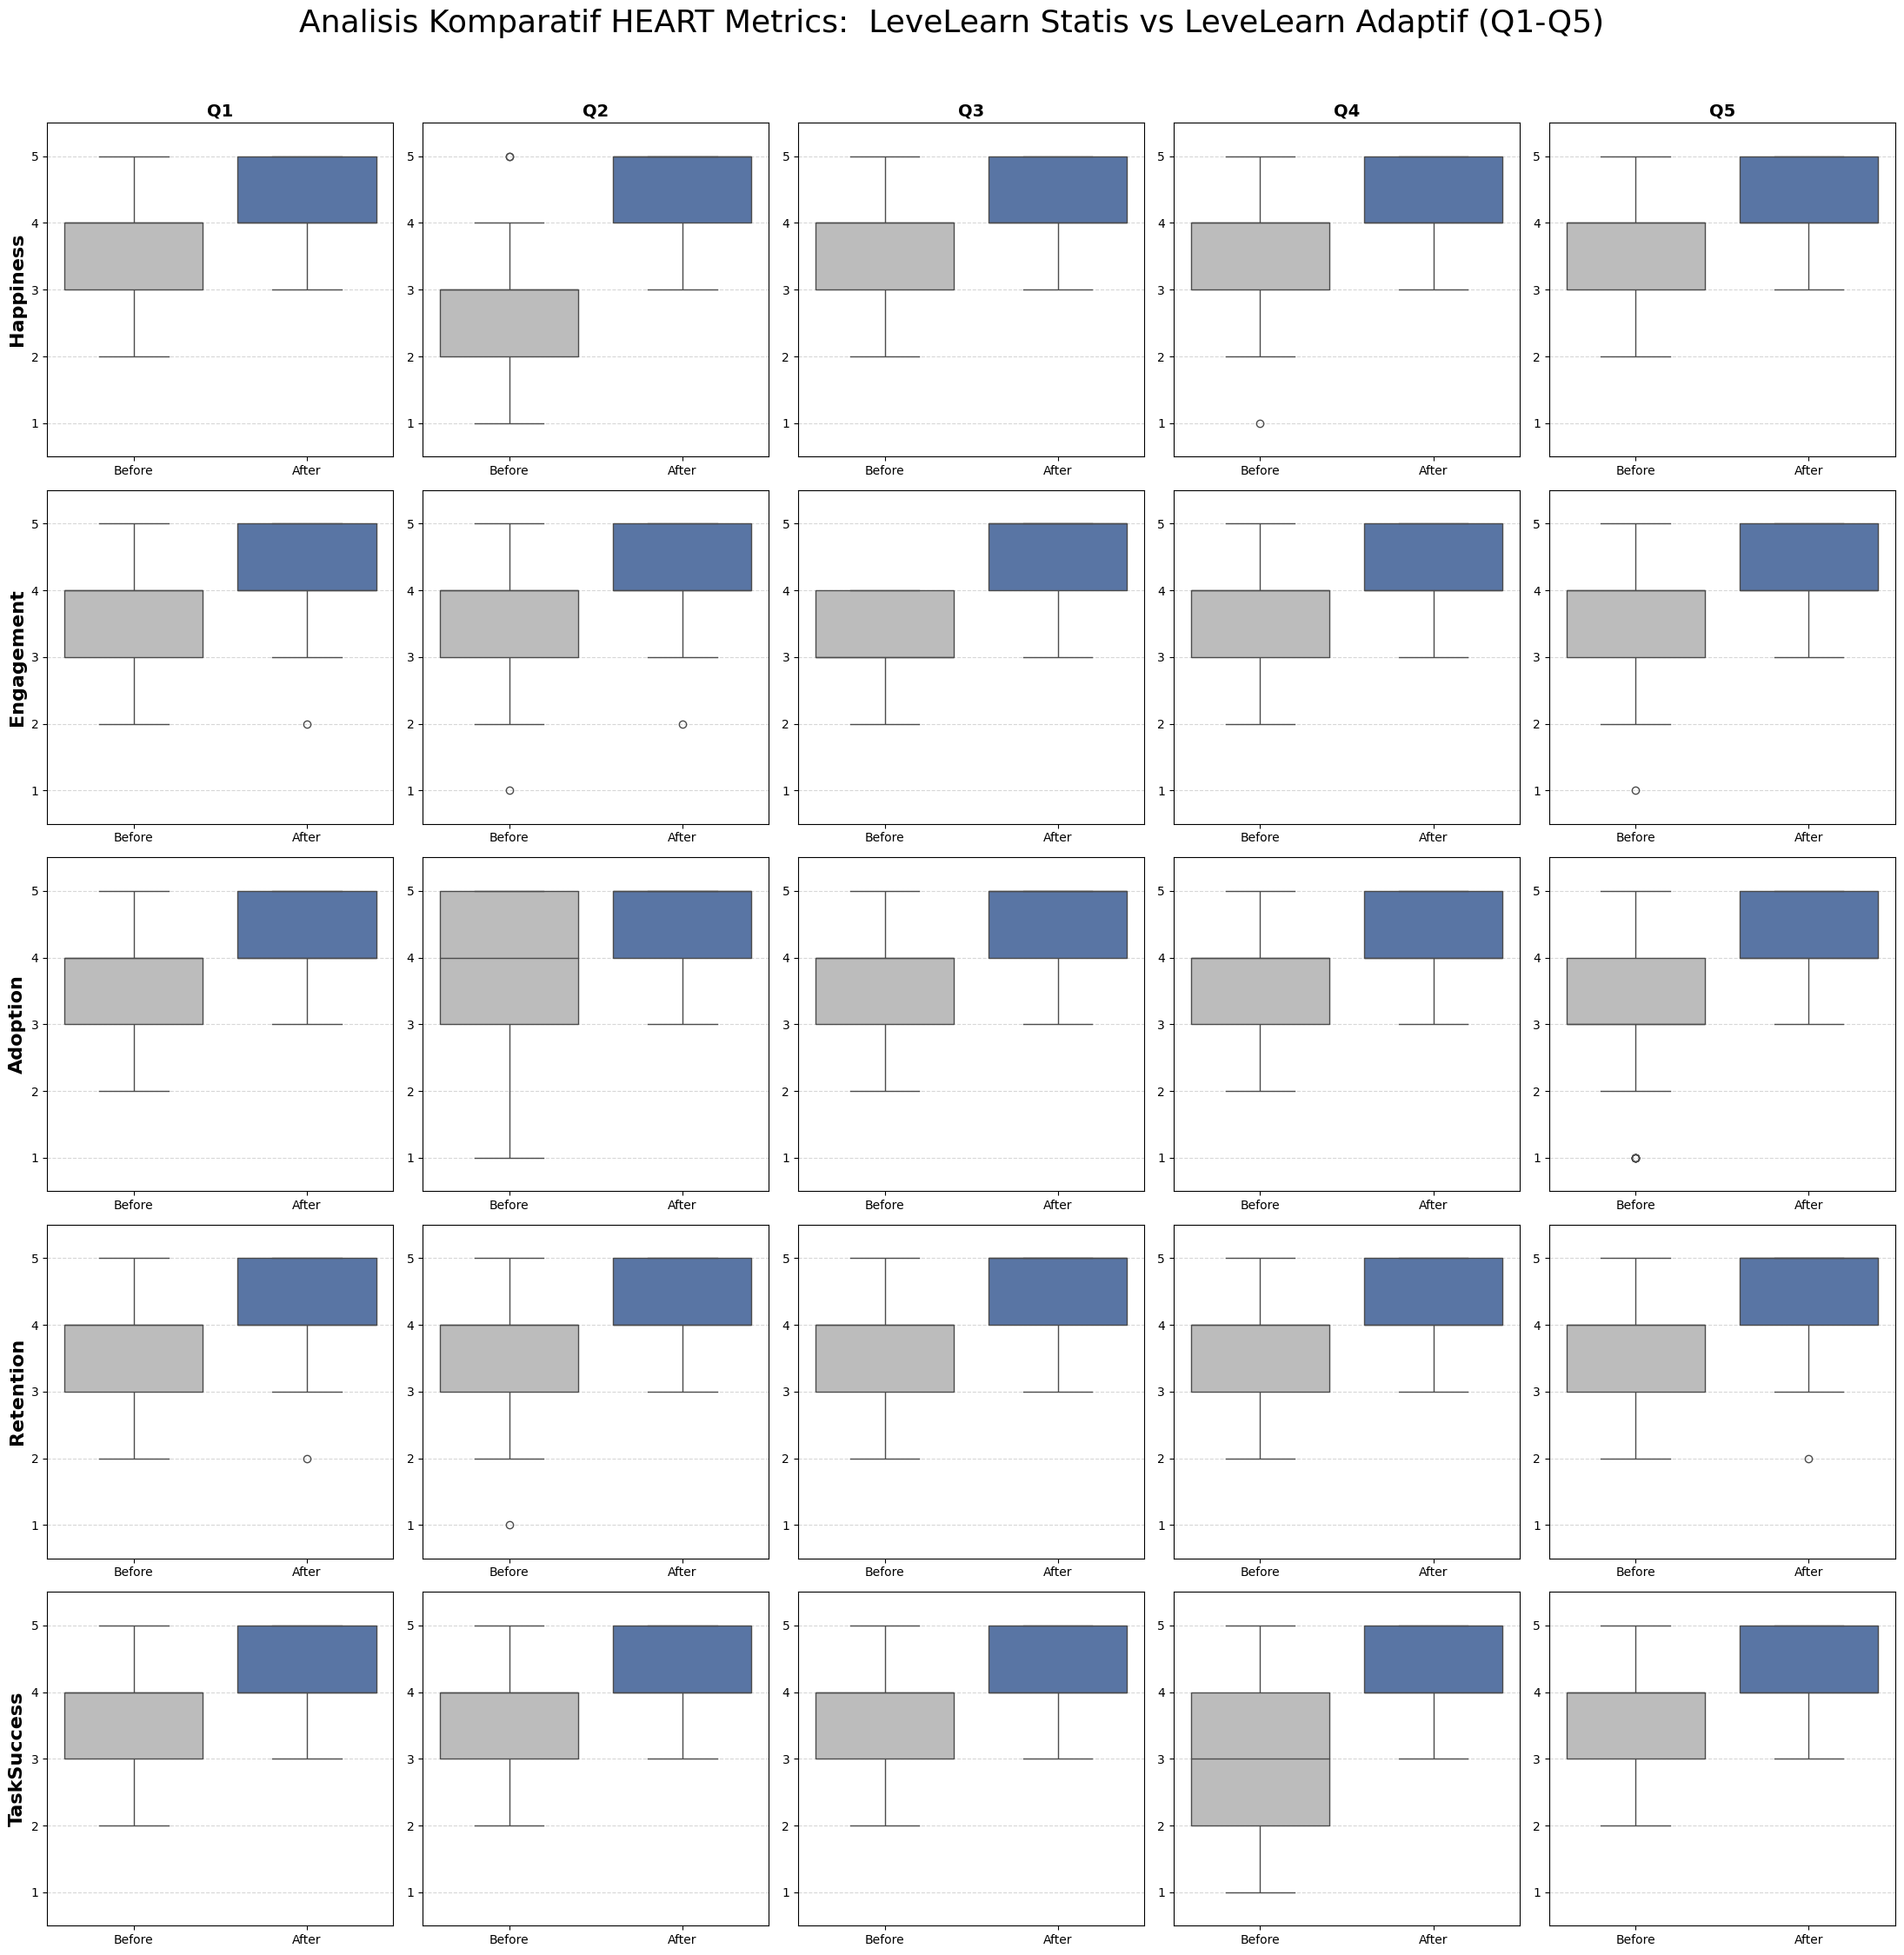

In [68]:
fig, axes = plt.subplots(5, 5, figsize=(22, 22))
fig.suptitle("Analisis Komparatif HEART Metrics:  LeveLearn Statis vs LeveLearn Adaptif (Q1-Q5)", fontsize=26, y=1.02)

aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']

for m_idx, metrik in enumerate(aspek):
    for q_idx in range(1, 6):
        ax = axes[m_idx, q_idx-1]

        col_base = f"{metrik}_Q{q_idx}"
        col_before = f"{col_base}_before"
        col_after = f"{col_base}_after"

        data_before = pd.to_numeric(df_paired[col_before], errors='coerce').fillna(0)
        data_after = pd.to_numeric(df_paired[col_after], errors='coerce').fillna(0)

        plot_df = pd.DataFrame({
            "Kondisi": ["Before"] * len(data_before) + ["After"] * len(data_after),
            "Skor": pd.concat([data_before, data_after], ignore_index=True)
        })

        sns.boxplot(x="Kondisi", y="Skor", data=plot_df, ax=ax,
                    hue="Kondisi", palette={"Before": "#bcbcbc", "After": "#4c72b0"},
                    legend=False)

        if m_idx == 0:
            ax.set_title(f"Q{q_idx}", fontsize=14, fontweight='bold')

        if q_idx == 1:
            ax.set_ylabel(metrik, fontsize=16, fontweight='bold')
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_ylim(0.5, 5.5) # Skala Likert 1-5
        ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

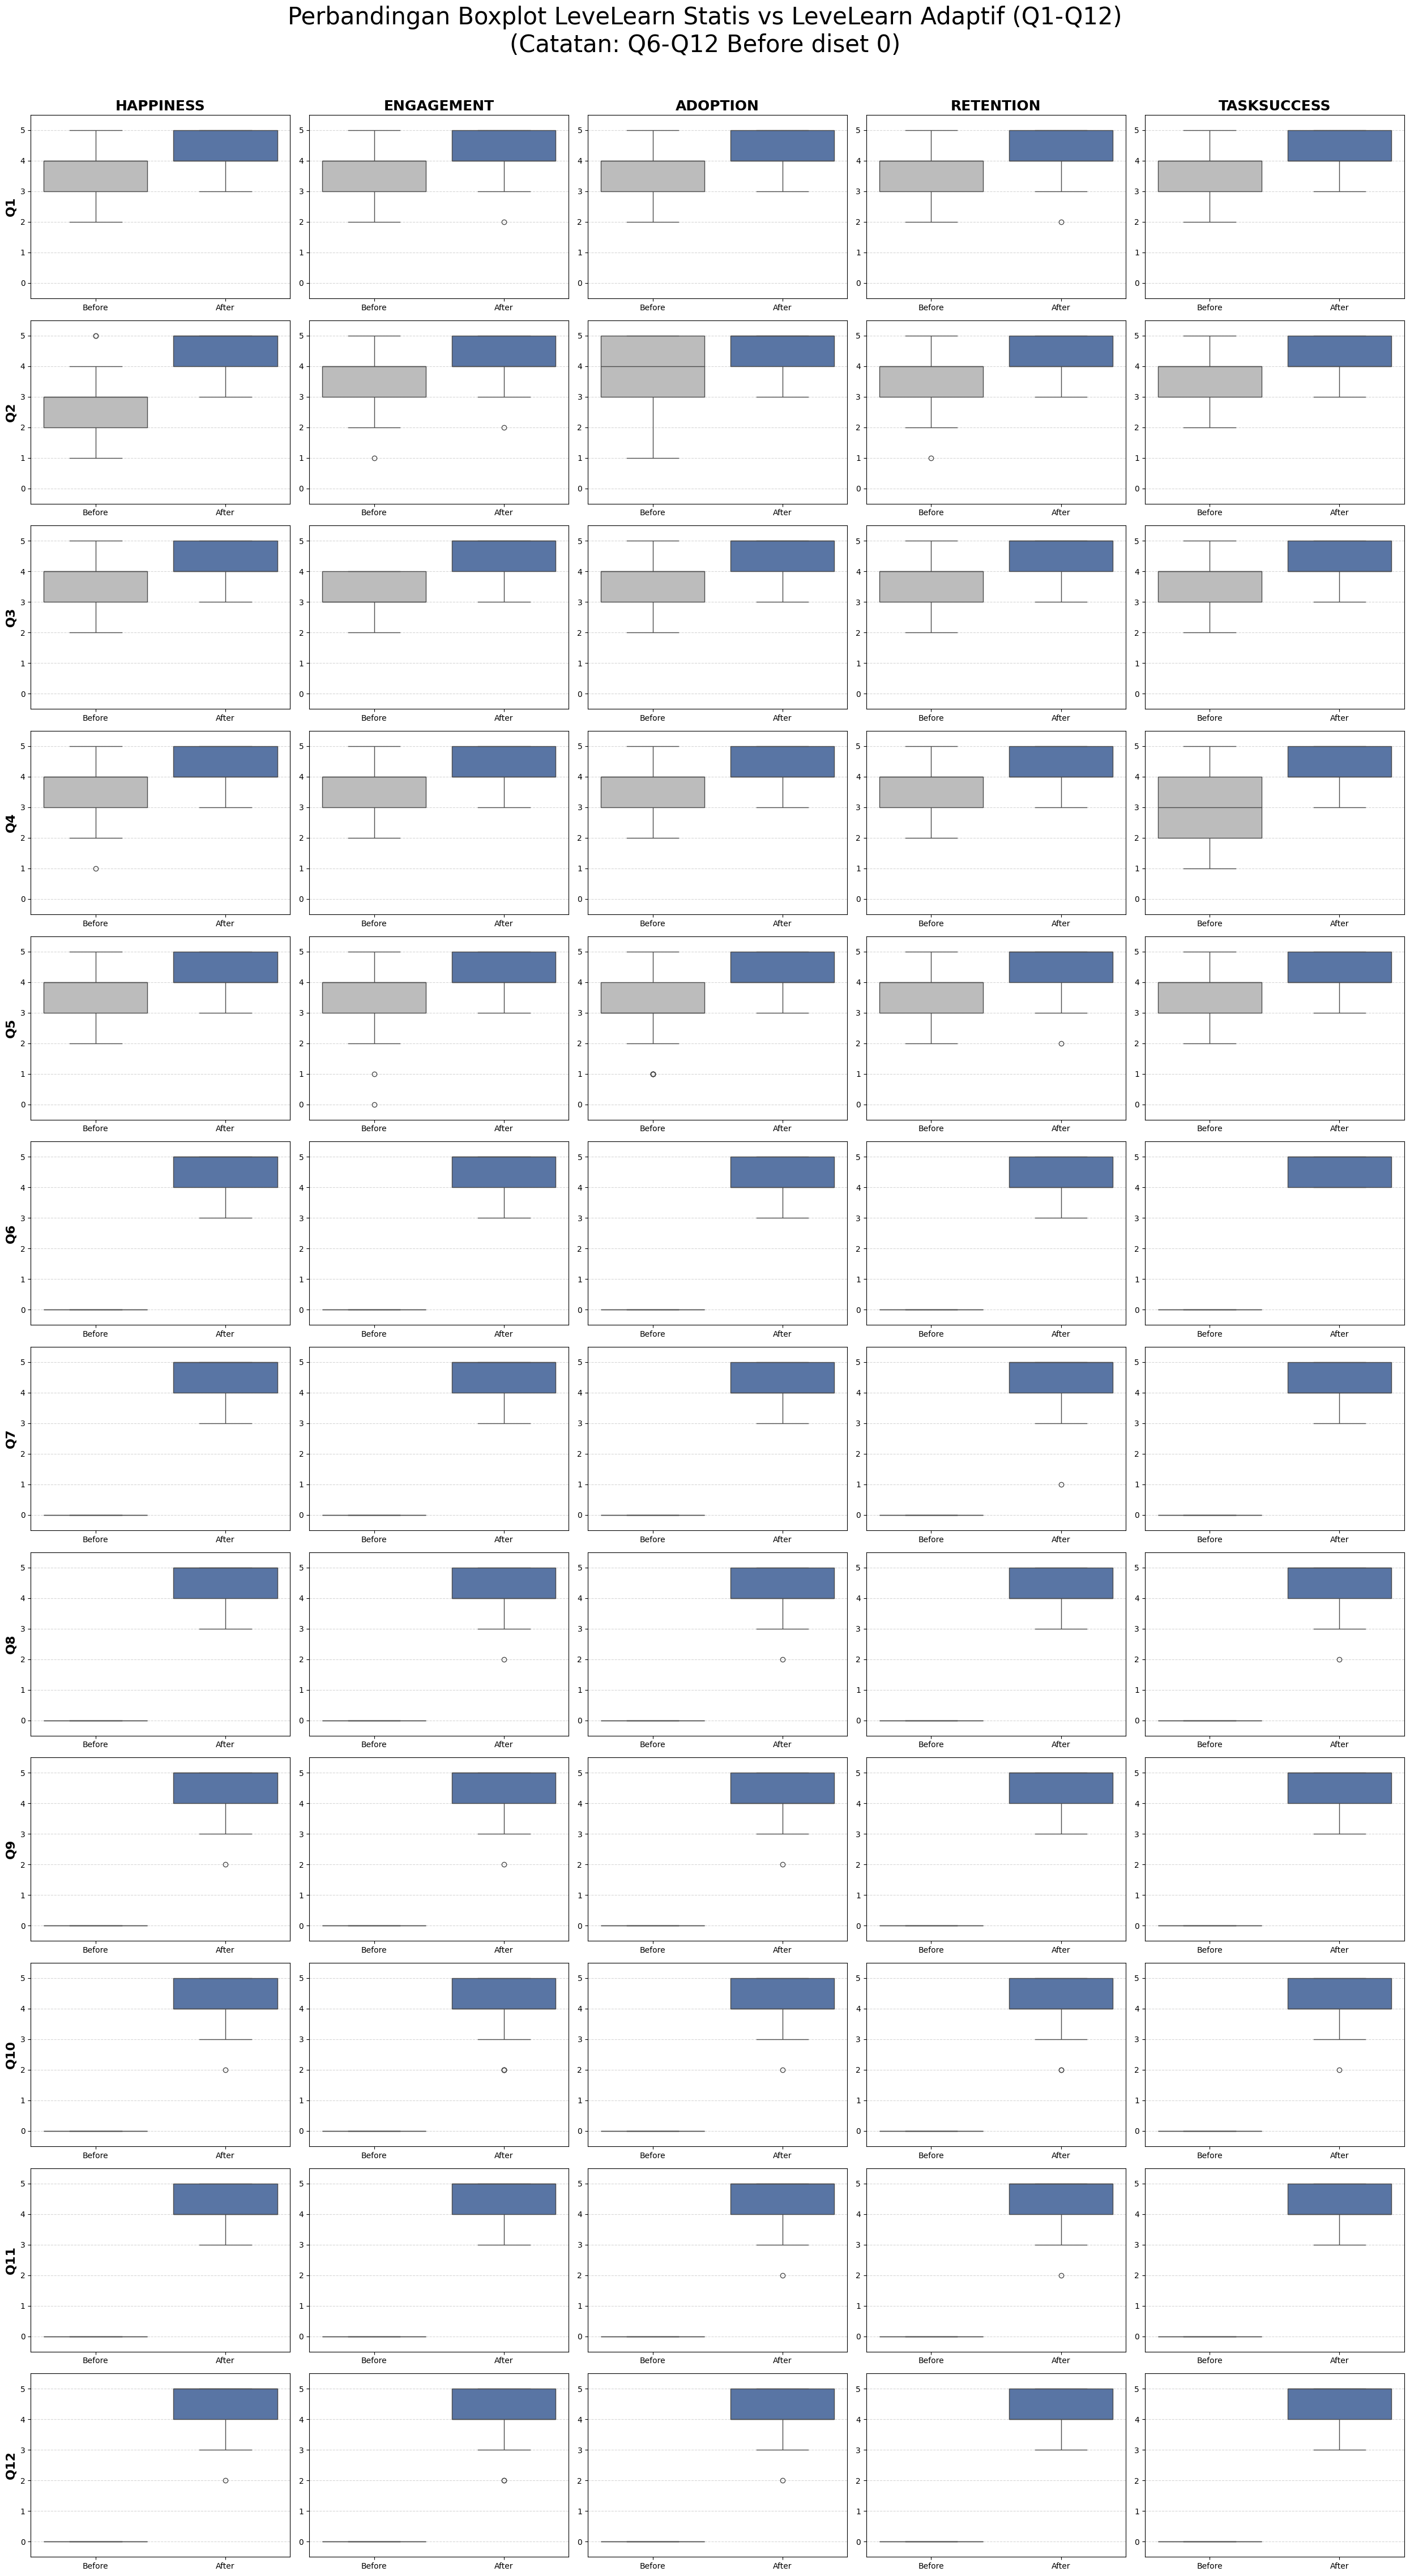

In [69]:
fig, axes = plt.subplots(12, 5, figsize=(25, 45))
fig.suptitle("Perbandingan Boxplot LeveLearn Statis vs LeveLearn Adaptif (Q1-Q12)\n(Catatan: Q6-Q12 Before diset 0)", fontsize=30, y=1.01)

aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']

for q_idx in range(1, 13):
    for m_idx, metrik in enumerate(aspek):
        ax = axes[q_idx-1, m_idx]
        col_base = f"{metrik}_Q{q_idx}"

        col_after = col_base + "_after" if col_base + "_after" in df_paired.columns else col_base
        data_after = pd.to_numeric(df_paired[col_after], errors='coerce').fillna(0)

        col_before = col_base + "_before"
        if q_idx <= 5 and col_before in df_paired.columns:
            data_before = pd.to_numeric(df_paired[col_before], errors='coerce').fillna(0)
        else:
            data_before = pd.Series([0] * len(df_paired))

        plot_df = pd.DataFrame({
            "Kondisi": ["Before"] * len(data_before) + ["After"] * len(data_after),
            "Skor": pd.concat([data_before, data_after], ignore_index=True)
        })

        sns.boxplot(x="Kondisi", y="Skor", data=plot_df, ax=ax,
                    hue="Kondisi", palette={"Before": "#bcbcbc", "After": "#4c72b0"},
                    legend=False)

        if q_idx == 1:
            ax.set_title(metrik.upper(), fontsize=18, fontweight='bold')

        if m_idx == 0:
            ax.set_ylabel(f"Q{q_idx}", fontsize=16, fontweight='bold')
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_ylim(-0.5, 5.5)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

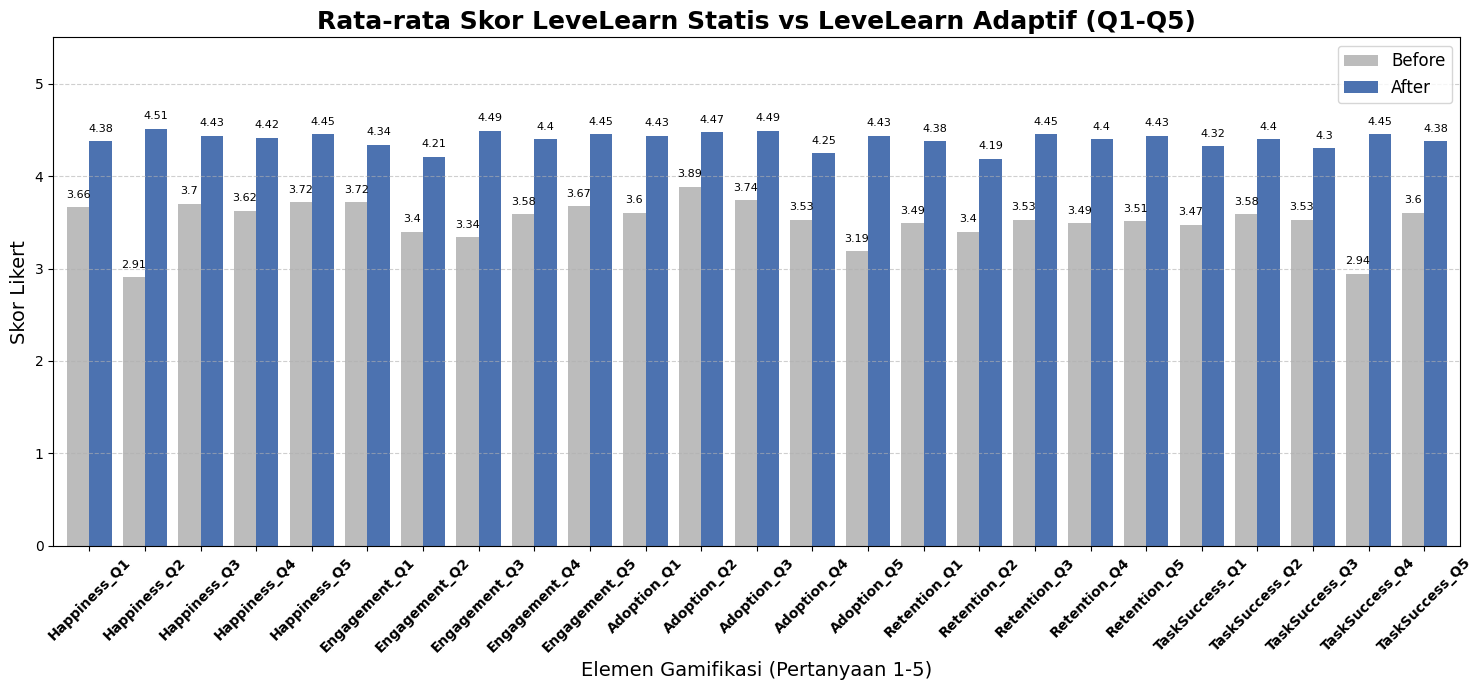

In [77]:
results_avg_q1_q5 = []
aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
target_columns = [f"{metric}_Q{i}" for metric in aspek for i in range(1, 6)]

for col in target_columns:
    col_after = col + "_after"
    col_before = col + "_before"

    val_after = pd.to_numeric(df_paired[col_after], errors='coerce').mean()
    val_before = pd.to_numeric(df_paired[col_before], errors='coerce').mean()

    results_avg_q1_q5.append({
        "Elemen": col,
        "Before": val_before,
        "After": val_after
    })

avg_q1_q5_df = pd.DataFrame(results_avg_q1_q5).set_index("Elemen")
ax = avg_q1_q5_df.plot(kind="bar", figsize=(15, 7), color=['#bcbcbc', '#4c72b0'], width=0.8)

plt.title("Rata-rata Skor LeveLearn Statis vs LeveLearn Adaptif (Q1-Q5)", fontsize=18, fontweight='bold')
plt.ylabel("Skor Likert", fontsize=14)
plt.xlabel("Elemen Gamifikasi (Pertanyaan 1-5)", fontsize=14)

plt.xticks(fontsize=10, rotation=45, fontweight='bold')
plt.ylim(0, 5.5) # Skala Likert 1-5
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 2)),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=8)

plt.tight_layout()
plt.show()

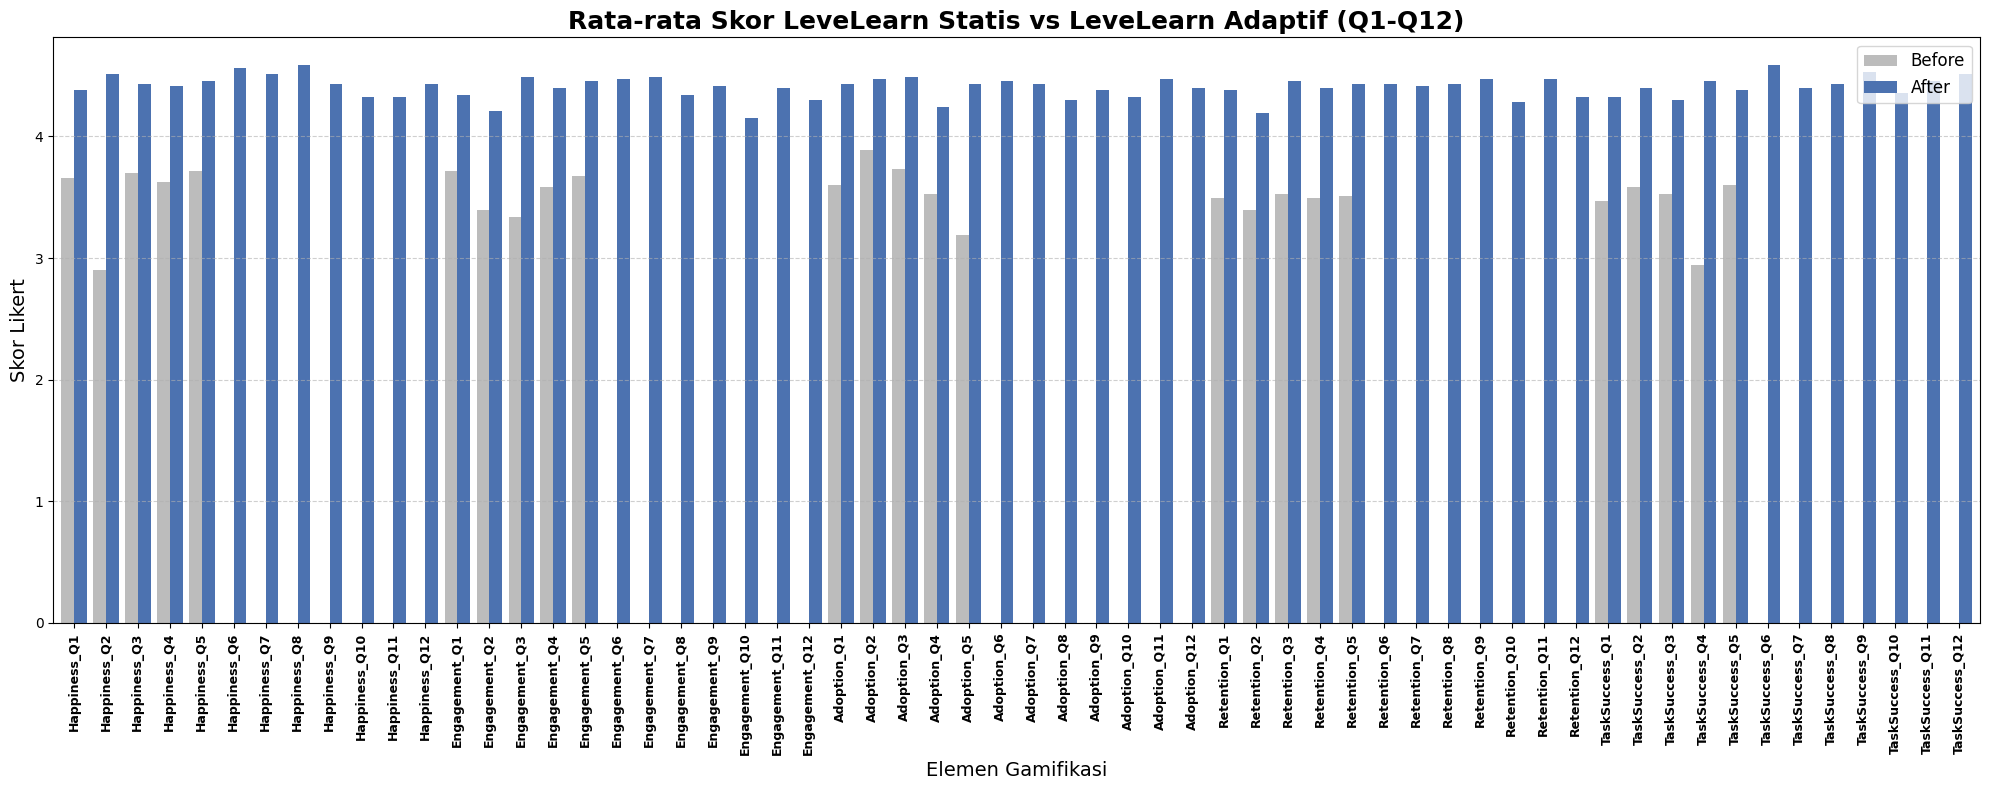

In [75]:
results_avg = []
aspek = ['Happiness', 'Engagement', 'Adoption', 'Retention', 'TaskSuccess']
all_columns = [f"{metric}_Q{i}" for metric in aspek for i in range(1, 13)]

for col in all_columns:
    q_number = int(col.split('_Q')[1])

    col_after = col + "_after" if col + "_after" in df_paired.columns else col
    val_after = pd.to_numeric(df_paired[col_after], errors='coerce').mean()

    if q_number <= 5:
        col_before = col + "_before"
        val_before = pd.to_numeric(df_paired[col_before], errors='coerce').mean()
    else:
        val_before = 0

    results_avg.append({
        "Elemen": col,
        "Before": val_before,
        "After": val_after
    })

avg_df = pd.DataFrame(results_avg).set_index("Elemen")

ax = avg_df.plot(kind="bar", figsize=(20, 8), color=['#bcbcbc', '#4c72b0'], width=0.8)

plt.title("Rata-rata Skor LeveLearn Statis vs LeveLearn Adaptif (Q1-Q12)", fontsize=18, fontweight='bold')
plt.ylabel("Skor Likert", fontsize=14)
plt.xlabel("Elemen Gamifikasi", fontsize=14)

plt.xticks(fontsize=9, rotation=90, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()